In [2]:
from pytorch_fid import fid_score

In [1]:
import numpy as np
import cv2

In [ ]:
fid_score.calculate_fid_given_paths([r'E:\work\Code\ColorAnything\example_output\b20', r'E:\work\Code\ColorAnything\examples_resized'], batch_size=4, device='cuda:0', dims=20)

  0%|          | 0/131 [00:03<?, ?it/s]


RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "c:\ProgramData\miniconda3\envs\rgb\lib\site-packages\torch\utils\data\_utils\worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "c:\ProgramData\miniconda3\envs\rgb\lib\site-packages\torch\utils\data\_utils\fetch.py", line 55, in fetch
    return self.collate_fn(data)
  File "c:\ProgramData\miniconda3\envs\rgb\lib\site-packages\torch\utils\data\_utils\collate.py", line 398, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
  File "c:\ProgramData\miniconda3\envs\rgb\lib\site-packages\torch\utils\data\_utils\collate.py", line 155, in collate
    return collate_fn_map[elem_type](batch, collate_fn_map=collate_fn_map)
  File "c:\ProgramData\miniconda3\envs\rgb\lib\site-packages\torch\utils\data\_utils\collate.py", line 271, in collate_tensor_fn
    out = elem.new(storage).resize_(l

In [23]:
from cocoloader import cocoloader
import torch
import cv2
from pytorch_fid import fid_score
test_iter = cocoloader('E:/work/Code/ColorAnything/data/test_small', batch_size=8, mode='lab') #


In [5]:
a = next(iter(test_iter))
len(a), a[0].shape

(2, torch.Size([4, 1, 224, 224]))

In [16]:
from model.ColorAnything import ColorAnything
net = ColorAnything(mode='lab', platform='windows')
net.load_state_dict(torch.load(f'checkpoints/lab/b20.pth', map_location='cpu'))

Backbone does not define embed_dims, using [embed_dim] * n_blocks=[384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384, 384] instead
Backbone does not define input_pad_size, using patch_size=16 instead


<All keys matched successfully>

In [7]:
x, y = next(iter(test_iter))
x.shape, y.shape

(torch.Size([4, 1, 224, 224]), torch.Size([4, 2, 224, 224]))

In [17]:
pred = net(x)
pred.shape

torch.Size([4, 2, 224, 224])

In [18]:
import numpy as np
import cv2
synth = np.concatenate((x.detach().numpy(), pred.detach().numpy()), axis=1)
synth.shape

(4, 3, 224, 224)

In [19]:
for i, pred in enumerate(synth):
    pred = np.transpose(pred, (1, 2, 0))
    pred = np.clip(pred, 0.0, 1.0)
    pred = (pred*255).astype('uint8') # to [0, 255]
    pred = cv2.resize(pred, (299, 299), interpolation=cv2.INTER_CUBIC)
    # pred = np.concatenate((grey_ori, pred), axis=2)
    pred = cv2.cvtColor(pred, cv2.COLOR_Lab2BGR)
    cv2.imwrite(f'./tests/labtest/{i}.png', pred)

In [20]:
synth.shape[0]

4

In [24]:
next(iter(test_iter))[0].shape[0]

8

In [27]:
import logging

# 配置日志记录
logging.basicConfig(filename='./logs/error.log', level=logging.ERROR, format='%(asctime)s - %(levelname)s - %(message)s')
asdfa

NameError: name 'asdfa' is not defined

In [26]:
asdfa

NameError: name 'asdfa' is not defined

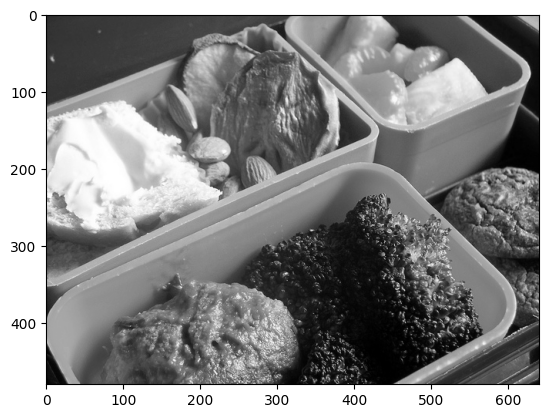

In [34]:
import numpy as np
import cv2
import os
from matplotlib import pyplot as plt
path = 'E:/work/Code/ColorAnything/examples/'
out_path = 'E:/work/Code/ColorAnything/examples_grey/'
filelist = os.listdir(path)
for file in filelist[0:1]:
    raw_img = cv2.imread(path+file)
    img = (np.sum(raw_img, axis=2, keepdims=True)/3.0).astype('uint8')
    img = np.concatenate((img, img, img), axis=2)
    plt.imshow(img)

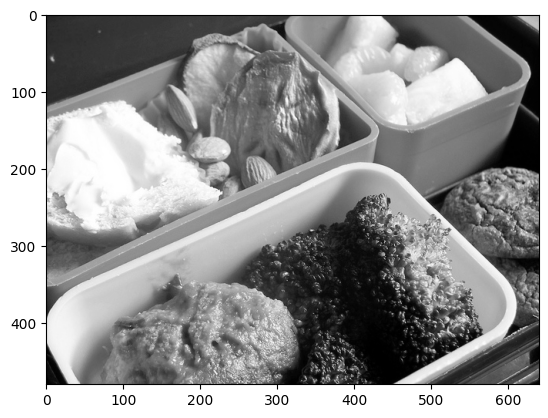

In [35]:
import numpy as np
import cv2
import os
from matplotlib import pyplot as plt
path = 'E:/work/Code/ColorAnything/examples/'
out_path = 'E:/work/Code/ColorAnything/examples_grey/'
filelist = os.listdir(path)
for file in filelist[0:1]:
    raw_img = cv2.imread(path+file)
    img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2Lab)[:, :, 0]
    img = cv2.merge((img, img, img))
    plt.imshow(img)

In [28]:

x = np.sum(x, axis=2, keepdims=True)/3.0
x = np.concatenate((x,x,x), axis=2)
x

array([[[ 2.,  2.,  2.],
        [ 5.,  5.,  5.]],

       [[ 8.,  8.,  8.],
        [11., 11., 11.]]])